In [1]:
import os
os.chdir("..")

In [ ]:
import numpy as np
import cv2 as cv
import copy
import matplotlib.pyplot as plt

from src.data.extract import read_image
from src.data import detect_noise, remove_noise
from src.visualization.plots import display_image, draw_keypoints
from src.models import seg
from src.descriptors.keypoints import harris, dog



In [3]:
database_folder = "data/raw/BBDD"
data_folder = "data/raw/qsd1_w4"
img_00_name = "00000.jpg"
img_01_name = "00001.jpg"
img_02_name = "00002.jpg"
img_03_name = "00003.jpg"
img_04_name = "bbdd_00000.jpg"
img_05_name = "bbdd_00004.jpg"
img_06_name = "bbdd_00002.jpg"
img_07_name = "bbdd_00003.jpg"

In [4]:
img_00 = read_image(os.path.join(data_folder, img_00_name))
img_01 = read_image(os.path.join(data_folder, img_01_name))
img_02 = read_image(os.path.join(data_folder, img_02_name))
img_03 = read_image(os.path.join(data_folder, img_03_name))


In [5]:
img_04 = read_image(os.path.join(database_folder, img_04_name))
img_05 = read_image(os.path.join(database_folder, img_05_name))
img_06 = read_image(os.path.join(database_folder, img_06_name))
img_07 = read_image(os.path.join(database_folder, img_07_name))


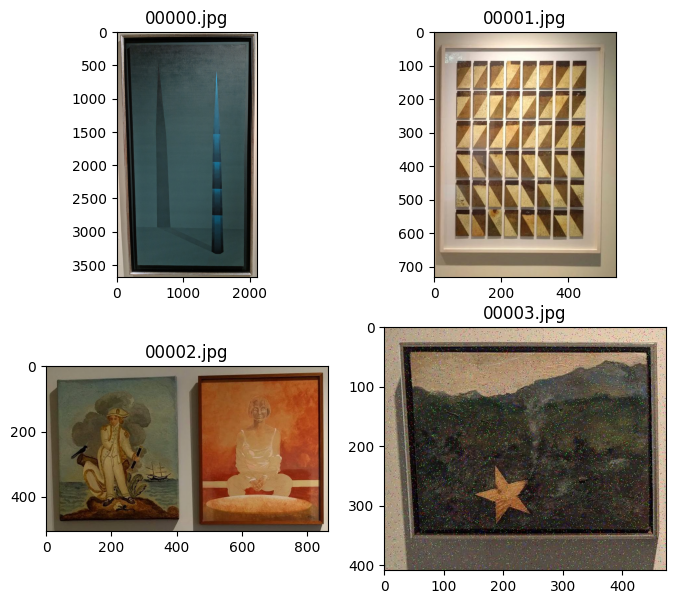

In [6]:
fig = plt.figure(figsize=(8,7))
ax1 = fig.add_subplot(221)  # left side
ax2 = fig.add_subplot(222)  # right side
display_image(img_00, ax1)
display_image(img_01, ax2)
ax3 = fig.add_subplot(223)  # left side
ax4 = fig.add_subplot(224)  # right side
display_image(img_02, ax3)
display_image(img_03, ax4)

ax1.set_title(img_00_name)
ax2.set_title(img_01_name)
ax3.set_title(img_02_name)
ax4.set_title(img_03_name)
plt.show()


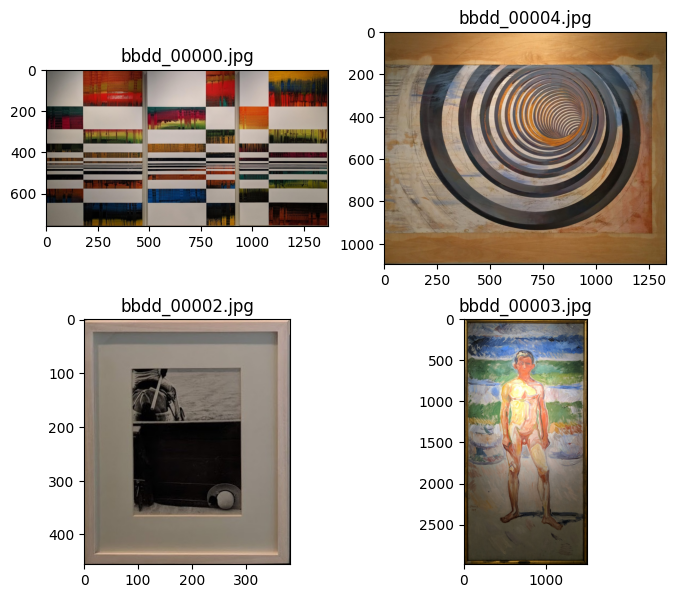

In [7]:
fig = plt.figure(figsize=(8,7))
ax1 = fig.add_subplot(221)  # left side
ax2 = fig.add_subplot(222)  # right side
display_image(img_04, ax1)
display_image(img_05, ax2)
ax3 = fig.add_subplot(223)  # left side
ax4 = fig.add_subplot(224)  # right side
display_image(img_06, ax3)
display_image(img_07, ax4)

ax1.set_title(img_04_name)
ax2.set_title(img_05_name)
ax3.set_title(img_06_name)
ax4.set_title(img_07_name)
plt.show()


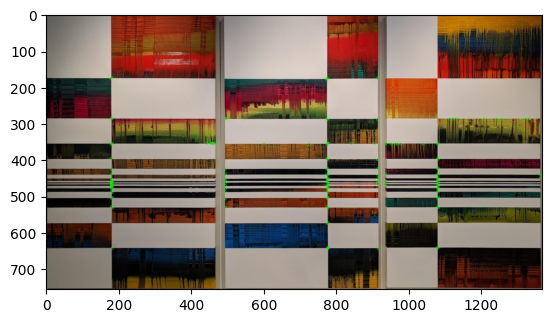

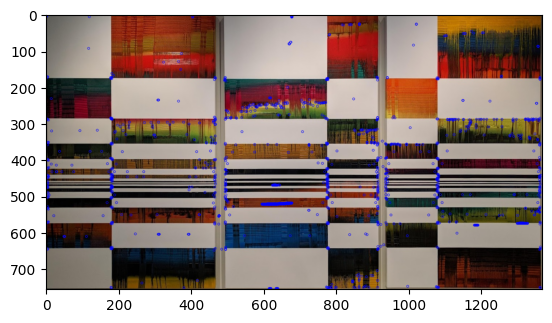

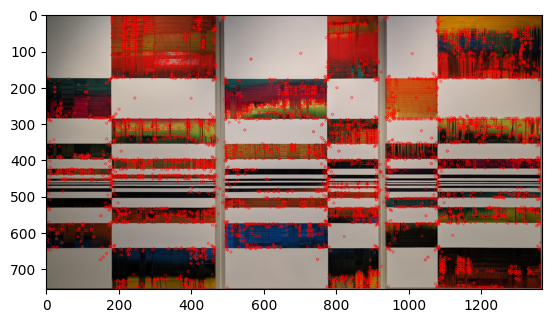

Harris: 141 keypoints
Harris-Laplacian: 1335 keypoints
DoG: 5731 keypoints


In [23]:

# 1) Harris with cv.cornerHarris
harris_kps, Rn = harris.detect_harris_keypoints_from_array(
    img_04, blockSize=3, ksize=3, k=0.04, thresh_rel=0.4, nms_ksize=3)
vis_harris = draw_keypoints(
    img_04, harris_kps, color=(0, 255, 0))

# 2) Harris-Laplacian (using cv.cornerHarris + Laplacian scale selection)
hl_kps = harris.detect_harris_laplacian_keypoints_from_array(img_04,
                            sigmas=(1.2, 1.6, 2.2, 3.0, 4.2, 6.0, 8.0, 16.0, 24.0, 30.0, 50.0),
                            blockSize=3, ksize=3, k=0.04)
vis_hl = draw_keypoints(img_04, hl_kps, color=(
    255, 0, 0))

# 3) DoG
dog_kps = dog.detect_dog_keypoints_from_array(img_04)
vis_hl = draw_keypoints(img_04, dog_kps, color=(0, 0, 255))


print(f"Harris: {len(harris_kps)} keypoints")
print(f"Harris-Laplacian: {len(hl_kps)} keypoints")
print(f"DoG: {len(dog_kps)} keypoints")


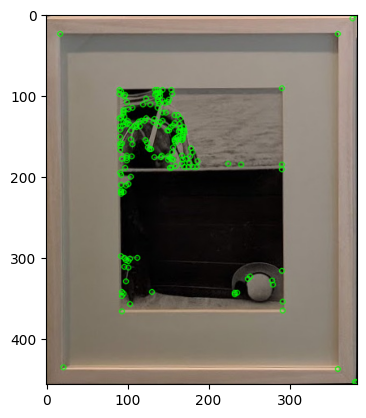

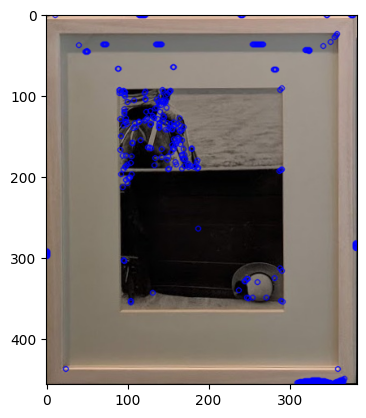

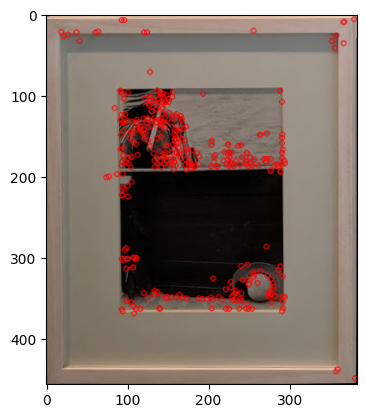

Harris: 178 keypoints
Harris-Laplacian: 456 keypoints
DoG: 377 keypoints


In [22]:
# 1) Harris with cv.cornerHarris
harris_kps, Rn = harris.detect_harris_keypoints_from_array(
    img_06, blockSize=3, ksize=3, k=0.04, thresh_rel=0.4, nms_ksize=3)
vis_harris = draw_keypoints(
    img_06, harris_kps, color=(0, 255, 0))

# 2) Harris-Laplacian (using cv.cornerHarris + Laplacian scale selection)
hl_kps = harris.detect_harris_laplacian_keypoints_from_array(img_06,
                            sigmas=(1.2, 1.6, 2.2, 3.0, 4.2, 6.0, 8.0, 16.0, 24.0, 30.0, 50.0),
                            blockSize=3, ksize=3, k=0.04)
vis_hl = draw_keypoints(img_06, hl_kps, color=(255, 0, 0))

# 3) DoG
dog_kps = dog.detect_dog_keypoints_from_array(img_06)
vis_hl = draw_keypoints(img_06, dog_kps, color=(0, 0, 255))

print(f"Harris: {len(harris_kps)} keypoints")
print(f"Harris-Laplacian: {len(hl_kps)} keypoints")
print(f"DoG: {len(dog_kps)} keypoints")


### Other experiments

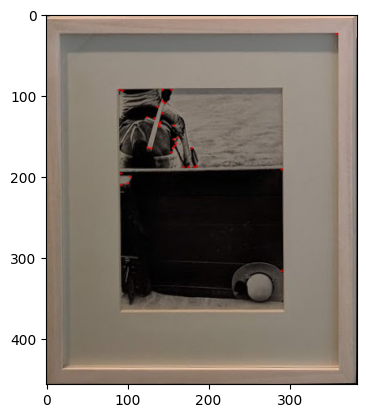

Harris-Laplacian (cv Harris + Laplacian): 34 keypoints


In [ ]:
from src.descriptors.grayscale import convert_img_to_gray_scale

img_gray = convert_img_to_gray_scale(img_06)
img_gray = img_gray.astype(np.float32) / 255.0
blur = cv.GaussianBlur(img_gray, (0, 0), sigmaX=1.2, sigmaY=1.2)
#display_image(blur)

# Harris response at this scale
H = cv.cornerHarris(blur, blockSize=3, ksize=3, k=0.04)
H = cv.normalize(H, None, alpha=0, beta=1, norm_type=cv.NORM_MINMAX)

# Spatial NMS on Harris
peaks = harris.local_maxima(H, nms_ksize=3, thresh=0.6 * H.max())

ys, xs = np.where(peaks)
keypoints = [(int(y), int(x), 1.2) for y, x in zip(ys, xs)]

vis_hl = draw_keypoints(img_06, keypoints, color=(
    0, 0, 255), radius=2, scale_to_radius=True)

display_image(vis_hl)
print(f"Harris-Laplacian (cv Harris + Laplacian): {len(keypoints)} keypoints")


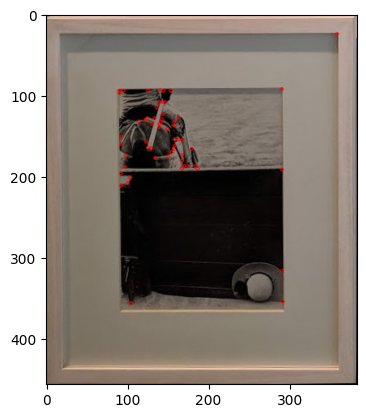

In [ ]:
from src.descriptors.grayscale import convert_img_to_gray_scale

sigma = 1.6

img_gray = convert_img_to_gray_scale(img_06)
img_gray = img_gray.astype(np.float32) / 255.0
blur = cv.GaussianBlur(img_gray, (0, 0), sigmaX=sigma, sigmaY=sigma)
#display_image(blur)

# Harris response at this scale
H = cv.cornerHarris(blur, blockSize=3, ksize=3, k=0.04)
H = cv.normalize(H, None, alpha=0, beta=1, norm_type=cv.NORM_MINMAX)

# Spatial NMS on Harris
peaks = harris.local_maxima(H, nms_ksize=3, thresh=0.7 * H.max())

ys, xs = np.where(peaks)
keypoints = [(int(y), int(x), sigma) for y, x in zip(ys, xs)]

vis_hl = draw_keypoints(img_06, keypoints, color=(
    0, 0, 255), radius=2, scale_to_radius=True)

display_image(vis_hl)

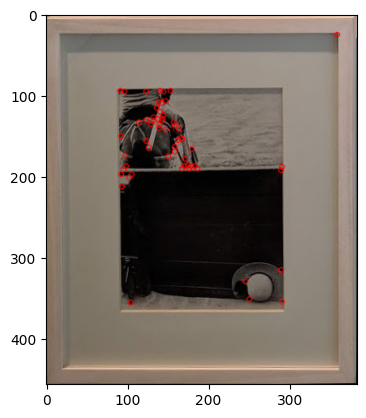

In [ ]:
from src.descriptors.grayscale import convert_img_to_gray_scale

sigma = 2.2

img_gray = convert_img_to_gray_scale(img_06)
img_gray = img_gray.astype(np.float32) / 255.0
blur = cv.GaussianBlur(img_gray, (0, 0), sigmaX=sigma, sigmaY=sigma)
#display_image(blur)

# Harris response at this scale
H = cv.cornerHarris(blur, blockSize=3, ksize=3, k=0.04)
H = cv.normalize(H, None, alpha=0, beta=1, norm_type=cv.NORM_MINMAX)

# Spatial NMS on Harris
peaks = harris.local_maxima(H, nms_ksize=3, thresh=0.76 * H.max())

ys, xs = np.where(peaks)
keypoints = [(int(y), int(x), sigma) for y, x in zip(ys, xs)]

vis_hl = draw_keypoints(img_06, keypoints, color=(
    0, 0, 255), radius=2, scale_to_radius=True)

display_image(vis_hl)

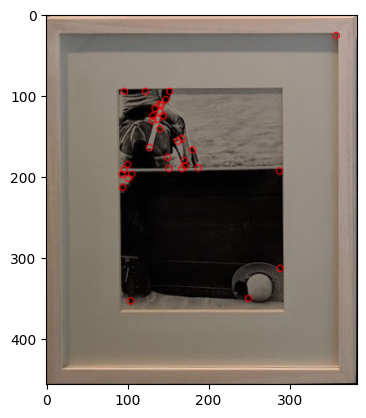

In [ ]:
from src.descriptors.grayscale import convert_img_to_gray_scale

sigma = 3.0

img_gray = convert_img_to_gray_scale(img_06)
img_gray = img_gray.astype(np.float32) / 255.0
blur = cv.GaussianBlur(img_gray, (0, 0), sigmaX=sigma, sigmaY=sigma)
#display_image(blur)

# Harris response at this scale
H = cv.cornerHarris(blur, blockSize=3, ksize=3, k=0.04)
H = cv.normalize(H, None, alpha=0, beta=1, norm_type=cv.NORM_MINMAX)

# Spatial NMS on Harris
peaks = harris.local_maxima(H, nms_ksize=3, thresh=0.84 * H.max())

ys, xs = np.where(peaks)
keypoints = [(int(y), int(x), sigma) for y, x in zip(ys, xs)]

vis_hl = draw_keypoints(img_06, keypoints, color=(
    0, 0, 255), radius=2, scale_to_radius=True)

display_image(vis_hl)

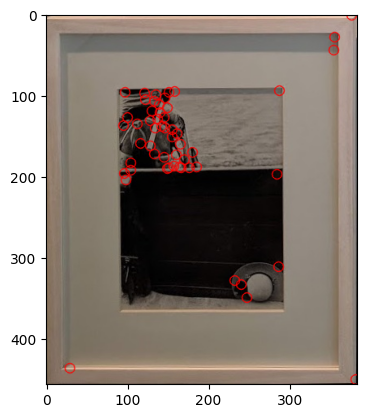

In [ ]:
from src.descriptors.grayscale import convert_img_to_gray_scale

sigma = 4.2

img_gray = convert_img_to_gray_scale(img_06)
img_gray = img_gray.astype(np.float32) / 255.0
blur = cv.GaussianBlur(img_gray, (0, 0), sigmaX=sigma, sigmaY=sigma)
#display_image(blur)

# Harris response at this scale
H = cv.cornerHarris(blur, blockSize=3, ksize=3, k=0.04)
H = cv.normalize(H, None, alpha=0, beta=1, norm_type=cv.NORM_MINMAX)

# Spatial NMS on Harris
peaks = harris.local_maxima(H, nms_ksize=3, thresh=0.93 * H.max())

ys, xs = np.where(peaks)
keypoints = [(int(y), int(x), sigma) for y, x in zip(ys, xs)]

vis_hl = draw_keypoints(img_06, keypoints, color=(
    0, 0, 255), radius=2, scale_to_radius=True)

display_image(vis_hl)

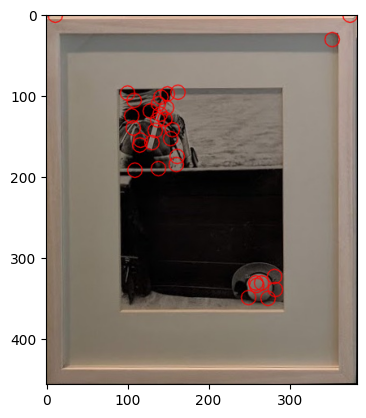

In [ ]:
from src.descriptors.grayscale import convert_img_to_gray_scale

sigma = 6.0

img_gray = convert_img_to_gray_scale(img_06)
img_gray = img_gray.astype(np.float32) / 255.0
blur = cv.GaussianBlur(img_gray, (0, 0), sigmaX=sigma, sigmaY=sigma)
#display_image(blur)

# Harris response at this scale
H = cv.cornerHarris(blur, blockSize=3, ksize=3, k=0.04)
H = cv.normalize(H, None, alpha=0, beta=1, norm_type=cv.NORM_MINMAX)

# Spatial NMS on Harris
peaks = harris.local_maxima(H, nms_ksize=3, thresh=0.98 * H.max())

ys, xs = np.where(peaks)
keypoints = [(int(y), int(x), sigma) for y, x in zip(ys, xs)]

vis_hl = draw_keypoints(img_06, keypoints, color=(
    0, 0, 255), radius=2, scale_to_radius=True)

display_image(vis_hl)

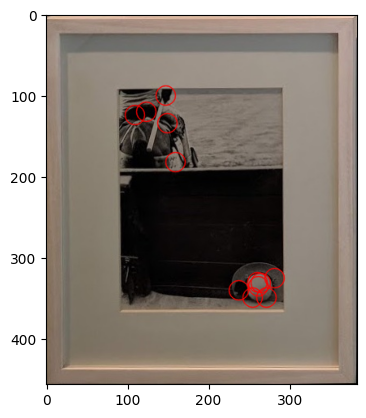

In [ ]:
from src.descriptors.grayscale import convert_img_to_gray_scale

sigma = 8.0

img_gray = convert_img_to_gray_scale(img_06)
img_gray = img_gray.astype(np.float32) / 255.0
blur = cv.GaussianBlur(img_gray, (0, 0), sigmaX=sigma, sigmaY=sigma)
#display_image(blur)

# Harris response at this scale
H = cv.cornerHarris(blur, blockSize=3, ksize=3, k=0.04)
H = cv.normalize(H, None, alpha=0, beta=1, norm_type=cv.NORM_MINMAX)

# Spatial NMS on Harris
peaks = harris.local_maxima(H, nms_ksize=3, thresh=0.9965 * H.max())

ys, xs = np.where(peaks)
keypoints = [(int(y), int(x), sigma) for y, x in zip(ys, xs)]

vis_hl = draw_keypoints(img_06, keypoints, color=(
    0, 0, 255), radius=2, scale_to_radius=True)

display_image(vis_hl)

In [ ]:
corners

array([[[2055,  750]],

       [[2035,   64]],

       [[ 123, 1004]],

       [[1992, 3629]],

       [[ 128, 1175]],

       [[ 215, 3619]],

       [[ 103,  881]],

       [[  95,   84]],

       [[ 130, 1228]],

       [[1693, 3634]],

       [[ 101,  845]],

       [[ 101,  833]],

       [[ 148, 1750]],

       [[ 107,  986]],

       [[ 105,  911]],

       [[ 130, 1640]],

       [[ 485, 3627]],

       [[1930, 3618]],

       [[  92,  454]],

       [[  88,  274]],

       [[  91,  334]],

       [[ 122, 1412]],

       [[ 247, 3624]],

       [[ 127, 1185]],

       [[  98,  107]]])

In [28]:
keypoints

[(0, 0, 1.2),
 (0, 345, 1.2),
 (0, 356, 1.2),
 (0, 362, 1.2),
 (0, 363, 1.2),
 (0, 364, 1.2),
 (0, 365, 1.2),
 (0, 366, 1.2),
 (0, 367, 1.2),
 (0, 368, 1.2),
 (1, 7, 1.2),
 (1, 20, 1.2),
 (1, 27, 1.2),
 (1, 30, 1.2),
 (1, 37, 1.2),
 (1, 42, 1.2),
 (1, 67, 1.2),
 (1, 83, 1.2),
 (1, 95, 1.2),
 (1, 105, 1.2),
 (1, 114, 1.2),
 (1, 122, 1.2),
 (1, 134, 1.2),
 (1, 145, 1.2),
 (1, 153, 1.2),
 (1, 165, 1.2),
 (1, 172, 1.2),
 (1, 182, 1.2),
 (1, 194, 1.2),
 (1, 205, 1.2),
 (1, 212, 1.2),
 (1, 225, 1.2),
 (1, 234, 1.2),
 (1, 240, 1.2),
 (1, 261, 1.2),
 (1, 274, 1.2),
 (1, 281, 1.2),
 (1, 294, 1.2),
 (1, 297, 1.2),
 (1, 323, 1.2),
 (1, 330, 1.2),
 (1, 333, 1.2),
 (1, 338, 1.2),
 (1, 352, 1.2),
 (1, 353, 1.2),
 (1, 354, 1.2),
 (1, 355, 1.2),
 (1, 356, 1.2),
 (1, 357, 1.2),
 (1, 360, 1.2),
 (1, 362, 1.2),
 (1, 363, 1.2),
 (1, 364, 1.2),
 (1, 365, 1.2),
 (1, 366, 1.2),
 (1, 367, 1.2),
 (1, 372, 1.2),
 (1, 380, 1.2),
 (3, 19, 1.2),
 (3, 27, 1.2),
 (3, 36, 1.2),
 (3, 41, 1.2),
 (3, 54, 1.2),
 (3, 59, 

### for qsd1_w4 noise removal and background removal must be applied first

In [12]:
# detect and remove noise

if detect_noise.noise_detector_laplace(img_00):
    img_00 = remove_noise.apply_median_filter_ycbcr(img_00)

if detect_noise.noise_detector_laplace(img_01):
    img_01 = remove_noise.apply_median_filter_ycbcr(img_01)
    
if detect_noise.noise_detector_laplace(img_02):
    img_02 = remove_noise.apply_median_filter_ycbcr(img_02)
    
if detect_noise.noise_detector_laplace(img_03):
    img_03 = remove_noise.apply_median_filter_ycbcr(img_03)


In [13]:
# remove background and segment

mask_img_00 = seg.segment_multiple_paintings(img_00)
segmented_img_00 = seg.apply_mask_to_image_mask(img_00, mask_img_00)

mask_img_01 = seg.segment_multiple_paintings(img_01)
segmented_img_01 = seg.apply_mask_to_image_mask(img_01, mask_img_01)

mask_img_02 = seg.segment_multiple_paintings(img_02)
segmented_img_02 = seg.apply_mask_to_image_mask(img_02, mask_img_02)

mask_img_03 = seg.segment_multiple_paintings(img_03)
segmented_img_03 = seg.apply_mask_to_image_mask(img_03, mask_img_03)

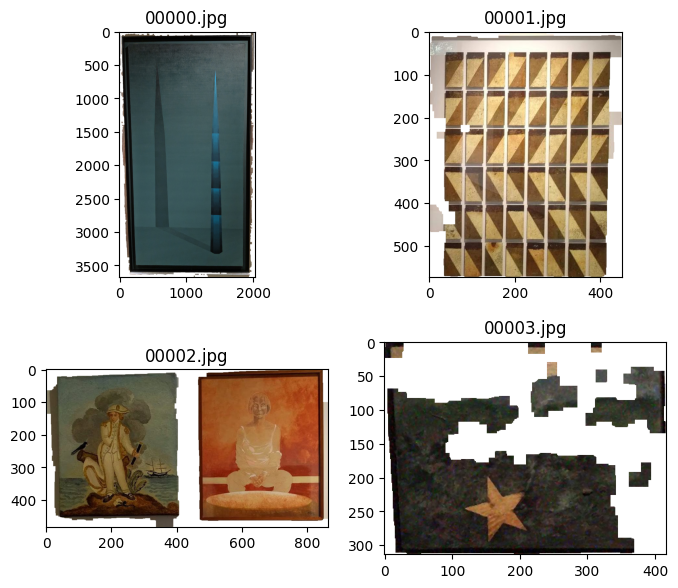

In [14]:
fig = plt.figure(figsize=(8,7))
ax1 = fig.add_subplot(221)  # left side
ax2 = fig.add_subplot(222)  # right side
display_image(segmented_img_00, ax1)
display_image(segmented_img_01, ax2)
ax3 = fig.add_subplot(223)  # left side
ax4 = fig.add_subplot(224)  # right side
display_image(segmented_img_02, ax3)
display_image(segmented_img_03, ax4)

ax1.set_title(img_00_name)
ax2.set_title(img_01_name)
ax3.set_title(img_02_name)
ax4.set_title(img_03_name)
plt.show()


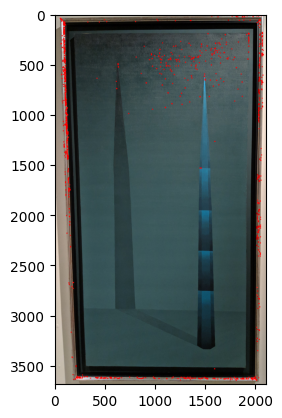

In [15]:

gray = cv.cvtColor(img_00,cv.COLOR_BGR2GRAY)

gray = np.float32(gray)
dst = cv.cornerHarris(gray,2,3,0.04)

#result is dilated for marking the corners
kernel = np.ones((10, 10), np.uint8)
dst = cv.dilate(dst, kernel)

# Threshold for an optimal value, it may vary depending on the image.
img_00_thres = copy.deepcopy(img_00)
img_00_thres[dst>0.01*dst.max()]=[0,0,255]

display_image(img_00_thres)

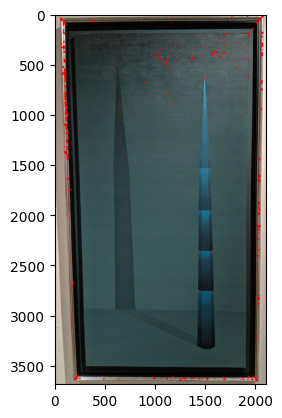

In [16]:

gray = cv.cvtColor(img_00,cv.COLOR_BGR2GRAY)

gray = np.float32(gray)
dst = cv.cornerHarris(gray,10,3,0.1)

#result is dilated for marking the corners
kernel = np.ones((10, 10), np.uint8)
dst = cv.dilate(dst, kernel)

# Threshold for an optimal value, it may vary depending on the image.
img_00_thres = copy.deepcopy(img_00)
img_00_thres[dst>0.01*dst.max()]=[0,0,255]

display_image(img_00_thres)

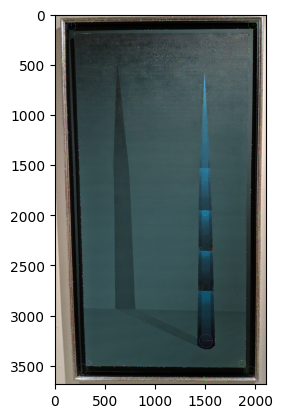

In [17]:
sift = cv.SIFT_create()
gray= cv.cvtColor(img_00,cv.COLOR_BGR2GRAY)
kp = sift.detect(gray,None)
#img_00_kp=cv.drawKeypoints(gray,kp,img_00)
img_00_kp = copy.deepcopy(img_00)
img_00_kp=cv.drawKeypoints(copy.deepcopy(img_00),kp,img_00_kp,flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
display_image(img_00_kp)

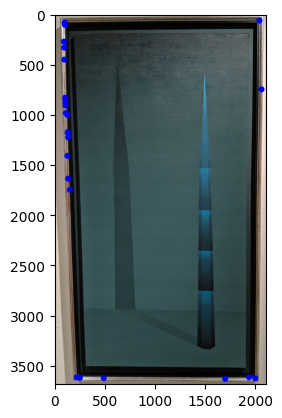

In [18]:
gray = cv.cvtColor(img_00,cv.COLOR_BGR2GRAY)

corners = cv.goodFeaturesToTrack(gray,25,0.01,10)
corners= np.intp(corners)

img_00_kp = copy.deepcopy(img_00)

for i in corners:
    x,y = i.ravel()
    cv.circle(img_00_kp,(x,y),30,255,-1)

display_image(img_00_kp)